# TP 2-4 : Modèles Sequence-to-Sequence et Question-Réponse

**UPB — NLP 2025-2026**

## Objectifs pédagogiques
- Comprendre l'architecture Encodeur-Décodeur (Seq2Seq).
- Implémenter un modèle Seq2Seq avec l'API fonctionnelle Keras.
- Appliquer le Seq2Seq à une tâche de Question-Réponse (caractère par caractère).
- Maîtriser le *teacher forcing* et le décalage de la cible.

## Données
Dataset **SQuAD v1.1** (Stanford Question Answering Dataset) : paires (question, réponse) extraites
du fichier JSON officiel `train-v1.1.json`.


> **Reproductibilité — données.** Le fichier `data/train-v1.1.json` (dataset SQuAD v1.1) n'est pas
> versionné dans le dépôt (voir `.gitignore`, qui exclut les datasets pour éviter que chacun pousse
> ses propres fichiers volumineux). Pour le récupérer avant d'exécuter ce notebook :
> ```bash
> mkdir -p data
> curl -L -o data/train-v1.1.json https://rajpurkar.github.io/SQuAD-explorer/dataset/train-v1.1.json
> ```

In [1]:
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)


## Partie A : Prétraitement SQuAD

### A.1 Chargement du fichier JSON SQuAD

On extrait uniquement le **texte** des questions et des réponses (pas les indices de position
`answer_start`), en ne conservant que la première réponse annotée pour chaque question.

In [2]:
SQUAD_PATH = "../data/train-v1.1.json"

with open(SQUAD_PATH, "r", encoding="utf-8") as f:
    squad = json.load(f)

print("Version SQuAD :", squad["version"])
print("Nombre d'articles :", len(squad["data"]))

raw_pairs = []
for article in squad["data"]:
    for paragraph in article["paragraphs"]:
        for qa in paragraph["qas"]:
            if not qa["answers"]:
                continue
            question = qa["question"].strip()
            answer = qa["answers"][0]["text"].strip()
            raw_pairs.append((question, answer))

print("Nombre total de paires (question, réponse) extraites :", len(raw_pairs))
print("Exemple :", raw_pairs[0])


Version SQuAD : 1.1
Nombre d'articles : 442
Nombre total de paires (question, réponse) extraites : 87599
Exemple : ('To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?', 'Saint Bernadette Soubirous')


### A.2 Filtrage des paires

On ne garde que les paires dont la réponse fait **moins de 50 caractères** et la question
**moins de 100 caractères**, comme demandé par l'énoncé.

On restreint également aux caractères **ASCII** (comme pour le nettoyage du TP 2-3) afin de garder
un vocabulaire de caractères compact — le corpus SQuAD brut contient de nombreux caractères Unicode
rares (accents, guillemets typographiques, symboles) qui gonfleraient inutilement `vocab_enc` et
`vocab_dec` sans apporter d'information utile à un modèle caractère-par-caractère.

In [3]:
def is_valid_pair(question, answer):
    return (
        0 < len(answer) < 50
        and 0 < len(question) < 100
        and question.isascii()
        and answer.isascii()
    )

filtered_pairs = [(q, a) for q, a in raw_pairs if is_valid_pair(q, a)]
print("Nombre de paires après filtrage (longueur + ASCII) :", len(filtered_pairs))


Nombre de paires après filtrage (longueur + ASCII) : 74448


### A.3 Sous-échantillonnage

L'entraînement d'un Seq2Seq caractère-par-caractère avec des tenseurs **one-hot 3D** sur
l'intégralité des ~74 000 paires filtrées demanderait une mémoire et un temps de calcul importants
pour un TP exécuté sur CPU. On tire donc un échantillon aléatoire reproductible
(`random_state=42`) de **6 500 paires** : 6 000 pour l'entraînement/validation, 500 conservées comme
ensemble de test totalement indépendant pour la Partie C (inférence et évaluation).

In [4]:
N_SAMPLES = 6500
N_TEST = 500

random.seed(SEED)
sample_pairs = random.sample(filtered_pairs, N_SAMPLES)

train_pairs, test_pairs = train_test_split(
    sample_pairs, test_size=N_TEST, random_state=SEED
)

print("Paires d'entraînement/validation :", len(train_pairs))
print("Paires de test (hold-out) :", len(test_pairs))

questions_train = [p[0] for p in train_pairs]
answers_train = [p[1] for p in train_pairs]


Paires d'entraînement/validation : 6000
Paires de test (hold-out) : 500


### A.4 Construction des vocabulaires de caractères

Deux vocabulaires distincts :
- `vocab_enc` : caractères apparaissant dans les **questions** (côté encodeur), avec un token
  `<PAD>` (index 0) pour le padding.
- `vocab_dec` : caractères apparaissant dans les **réponses** (côté décodeur), avec les tokens
  spéciaux `<PAD>` (index 0), `<START>` et `<END>` nécessaires au *teacher forcing*.

In [5]:
PAD_TOKEN = "<PAD>"
START_TOKEN = "<START>"
END_TOKEN = "<END>"

enc_chars = sorted(set("".join(questions_train)))
dec_chars = sorted(set("".join(answers_train)))

vocab_enc = {PAD_TOKEN: 0}
vocab_enc.update({ch: i + 1 for i, ch in enumerate(enc_chars)})

vocab_dec = {PAD_TOKEN: 0, START_TOKEN: 1, END_TOKEN: 2}
vocab_dec.update({ch: i + 3 for i, ch in enumerate(dec_chars)})

idx2char_enc = {i: ch for ch, i in vocab_enc.items()}
idx2char_dec = {i: ch for ch, i in vocab_dec.items()}

vocab_enc_size = len(vocab_enc)
vocab_dec_size = len(vocab_dec)

print("Taille vocab_enc (questions) :", vocab_enc_size)
print("Taille vocab_dec (réponses) :", vocab_dec_size)


Taille vocab_enc (questions) : 81
Taille vocab_dec (réponses) : 82


### A.5 Encodage en séquences d'entiers et padding

- `max_len_question` : longueur max observée dans l'échantillon d'entraînement (question).
- `max_len_answer` : longueur max observée + 1 (pour la place du token `<START>`/`<END>`).

Les séquences d'entrée du décodeur sont la réponse **préfixée** par `<START>` ; les cibles sont la
réponse **suffixée** par `<END>` (décalage d'un cran — *teacher forcing*).

**Choix important — padding à gauche côté encodeur.** L'encodeur ne transmet au décodeur que son
**dernier** état caché `(state_h, state_c)` (cf. Partie B). Si on complète les questions courtes
avec des `<PAD>` **à la fin** (post-padding), le LSTM continue de tourner sur une longue suite de
pas `<PAD>` identiques après le dernier vrai caractère : l'état final s'en trouve « lavé » et
converge vers un point fixe indépendant du contenu de la question, quasiment identique pour toutes
les questions. On observe alors expérimentalement un *mode collapse* du décodeur (il génère
toujours la même réponse, quelle que soit la question — un cas concret et particulièrement parlant
du problème de *bottleneck* discuté en Partie D). En **pré-paddant** l'encodeur (les `<PAD>` en
tête, les vrais caractères à la fin), le dernier pas traité par le LSTM est toujours un vrai
caractère de la question : l'état final conserve l'information utile. Le décodeur (entrée/cible),
lui, n'est pas concerné par ce problème : il est utilisé caractère par caractère à l'inférence et
s'arrête dès `<END>`, donc le padding de fin de séquence n'influence jamais la génération.

In [6]:
max_len_question = max(len(q) for q in questions_train)
max_len_answer = max(len(a) for a in answers_train) + 1  # +1 pour <START>/<END>

print("max_len_question :", max_len_question)
print("max_len_answer   :", max_len_answer)


def encode_question(text, vocab, max_len):
    # Padding à GAUCHE (pre-padding) : voir la justification ci-dessus.
    ids = [vocab[ch] for ch in text][:max_len]
    return [vocab[PAD_TOKEN]] * max(0, max_len - len(ids)) + ids


def encode_decoder_input(text, vocab, max_len):
    ids = [vocab[START_TOKEN]] + [vocab[ch] for ch in text]
    return ids[:max_len] + [vocab[PAD_TOKEN]] * max(0, max_len - len(ids))


def encode_decoder_target(text, vocab, max_len):
    ids = [vocab[ch] for ch in text] + [vocab[END_TOKEN]]
    return ids[:max_len] + [vocab[PAD_TOKEN]] * max(0, max_len - len(ids))


def build_arrays(pairs, vocab_enc, vocab_dec, max_len_question, max_len_answer):
    enc_seqs, dec_in_seqs, dec_target_seqs = [], [], []
    for question, answer in pairs:
        # on ignore les caractères de la réponse absents de vocab_dec (hors échantillon d'entraînement)
        if any(ch not in vocab_dec for ch in answer) or any(ch not in vocab_enc for ch in question):
            continue
        enc_seqs.append(encode_question(question, vocab_enc, max_len_question))
        dec_in_seqs.append(encode_decoder_input(answer, vocab_dec, max_len_answer))
        dec_target_seqs.append(encode_decoder_target(answer, vocab_dec, max_len_answer))
    return np.array(enc_seqs), np.array(dec_in_seqs), np.array(dec_target_seqs)


encoder_input_seq, decoder_input_seq, decoder_target_seq = build_arrays(
    train_pairs, vocab_enc, vocab_dec, max_len_question, max_len_answer
)

print("encoder_input_seq  :", encoder_input_seq.shape)
print("decoder_input_seq  :", decoder_input_seq.shape)
print("decoder_target_seq :", decoder_target_seq.shape)


max_len_question : 99
max_len_answer   : 50


encoder_input_seq  : (6000, 99)
decoder_input_seq  : (6000, 50)
decoder_target_seq : (6000, 50)


### A.6 One-hot encoding 3D

Chaque séquence d'entiers est convertie en tenseur one-hot `(n_samples, max_len, vocab_size)`,
au format attendu par les couches `LSTM` de Keras.

In [7]:
def one_hot_encode(int_seqs, vocab_size):
    n, max_len = int_seqs.shape
    onehot = np.zeros((n, max_len, vocab_size), dtype="float32")
    for i in range(n):
        for t, idx in enumerate(int_seqs[i]):
            onehot[i, t, idx] = 1.0
    return onehot


encoder_input_data = one_hot_encode(encoder_input_seq, vocab_enc_size)
decoder_input_data = one_hot_encode(decoder_input_seq, vocab_dec_size)
decoder_target_data = one_hot_encode(decoder_target_seq, vocab_dec_size)

print("encoder_input_data  :", encoder_input_data.shape)
print("decoder_input_data  :", decoder_input_data.shape)
print("decoder_target_data :", decoder_target_data.shape)


encoder_input_data  : (6000, 99, 81)
decoder_input_data  : (6000, 50, 82)
decoder_target_data : (6000, 50, 82)


## Partie B : Architecture Seq2Seq

### B.1 Encodeur

`Input(shape=(max_len_question, vocab_enc_size))` suivi d'une couche `LSTM(256, return_state=True)`
dont on récupère `output`, `state_h`, `state_c`. Seuls les états `(state_h, state_c)` — le
**vecteur de contexte** — sont transmis au décodeur ; `output` n'est pas utilisé.

In [8]:
LATENT_DIM = 256

encoder_inputs = Input(shape=(max_len_question, vocab_enc_size), name="encoder_inputs")
encoder_lstm = LSTM(LATENT_DIM, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]


### B.2 Décodeur

`Input(shape=(max_len_answer, vocab_dec_size))` suivi d'une couche
`LSTM(256, return_sequences=True, return_state=True)` initialisée avec les états de l'encodeur
(`initial_state=[state_h, state_c]`), puis une couche `Dense(vocab_dec_size, softmax)` appliquée à
chaque pas de temps (implicite grâce à `return_sequences=True`, équivalent à un `TimeDistributed`).

In [9]:
decoder_inputs = Input(shape=(max_len_answer, vocab_dec_size), name="decoder_inputs")
decoder_lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

decoder_dense = Dense(vocab_dec_size, activation="softmax", name="decoder_dense")
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs, name="seq2seq_qa")
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "seq2seq_qa"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 99, 81)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 50, 82)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    346,112 │ encoder_inputs[0… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 50, 256), │    347,136 │ decoder_inputs[0… │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 50, 82)    │     21,074 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 714,322 (2.72 MB)

 Trainable params: 714,322 (2.72 MB)

 Non-trainable params: 0 (0.00 B)

### B.3 Entraînement

`batch_size=64`, `epochs=20`, avec 10% des données d'entraînement réservées à la validation.

In [10]:
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=64,
    epochs=20,
    validation_split=0.1,
)


Epoch 1/20


 1/85 ━━━━━━━━━━━━━━━━━━━━ 2:14 2s/step - accuracy: 0.0072 - loss: 4.4377

 2/85 ━━━━━━━━━━━━━━━━━━━━ 12s 146ms/step - accuracy: 0.2534 - loss: 4.3810

 3/85 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.3968 - loss: 4.3172

 4/85 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.4696 - loss: 4.2441

...

82/85 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7778 - loss: 0.7653

83/85 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7776 - loss: 0.7656

84/85 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7776 - loss: 0.7652

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7775 - loss: 0.7656

85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - accuracy: 0.7775 - loss: 0.7656 - val_accuracy: 0.7636 - val_loss: 0.8101


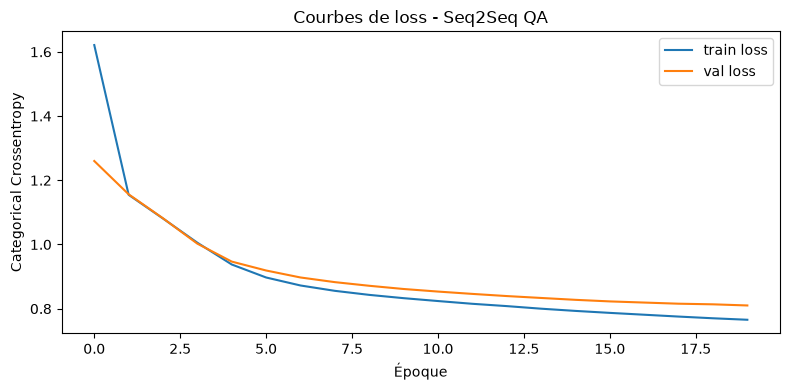

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Époque")
plt.ylabel("Categorical Crossentropy")
plt.title("Courbes de loss - Seq2Seq QA")
plt.legend()
plt.tight_layout()
plt.savefig("seq2seq_loss.png", dpi=120)
plt.show()


## Partie C : Inférence et évaluation

### C.1 Modèles d'inférence séparés

En inférence on ne peut pas utiliser directement `model` : le décodeur d'entraînement reçoit toute
la séquence cible d'un coup (teacher forcing), alors qu'à l'inférence on ne connaît pas la réponse
et on doit la générer **un caractère à la fois**, en réinjectant le caractère prédit à l'étape
précédente. On réutilise les couches `encoder_lstm`, `decoder_lstm` et `decoder_dense` déjà
entraînées, mais dans deux modèles Keras séparés :
- `encoder_model` : question → états `(state_h, state_c)`.
- `decoder_model` : (caractère précédent one-hot, états) → (distribution sur le prochain caractère,
  nouveaux états), appelé en boucle.

In [12]:
encoder_model = Model(encoder_inputs, encoder_states, name="encoder_inference")

decoder_state_input_h = Input(shape=(LATENT_DIM,), name="decoder_state_input_h")
decoder_state_input_c = Input(shape=(LATENT_DIM,), name="decoder_state_input_c")
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_single_input = Input(shape=(1, vocab_dec_size), name="decoder_single_input")
decoder_single_outputs, state_h_inf, state_c_inf = decoder_lstm(
    decoder_single_input, initial_state=decoder_states_inputs
)
decoder_states_inf = [state_h_inf, state_c_inf]
decoder_single_outputs = decoder_dense(decoder_single_outputs)

decoder_model = Model(
    [decoder_single_input] + decoder_states_inputs,
    [decoder_single_outputs] + decoder_states_inf,
    name="decoder_inference",
)


### C.2 `answer_question` : génération caractère par caractère

In [13]:
def encode_input_question(question, vocab_enc, max_len_question):
    ids = encode_question(question, vocab_enc, max_len_question)
    return one_hot_encode(np.array([ids]), len(vocab_enc))


def answer_question(question, max_len=None):
    if max_len is None:
        max_len = max_len_answer

    input_seq = encode_input_question(question, vocab_enc, max_len_question)
    states_value = encoder_model.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, 1, vocab_dec_size), dtype="float32")
    target_seq[0, 0, vocab_dec[START_TOKEN]] = 1.0

    decoded_answer = ""
    for _ in range(max_len):
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        sampled_idx = int(np.argmax(output_tokens[0, -1, :]))
        sampled_char = idx2char_dec[sampled_idx]

        if sampled_char == END_TOKEN:
            break
        if sampled_char != PAD_TOKEN:
            decoded_answer += sampled_char

        target_seq = np.zeros((1, 1, vocab_dec_size), dtype="float32")
        target_seq[0, 0, sampled_idx] = 1.0
        states_value = [h, c]

    return decoded_answer


### C.3 Test qualitatif sur 5 questions

On ne garde, pour ce test comme pour l'évaluation quantitative, que les paires de test dont tous
les caractères sont couverts par `vocab_enc`/`vocab_dec` (construits sur l'échantillon
d'entraînement) — un caractère jamais vu à l'entraînement ne peut pas être encodé.

In [14]:
usable_test_pairs = [
    (q, a) for q, a in test_pairs
    if all(ch in vocab_enc for ch in q) and all(ch in vocab_dec for ch in a)
]
print("Paires de test utilisables :", len(usable_test_pairs), "/", len(test_pairs))

random.seed(SEED)
demo_pairs = random.sample(usable_test_pairs, 5)

rows = []
for question, expected in demo_pairs:
    predicted = answer_question(question)
    rows.append({"question": question, "réponse attendue": expected, "réponse prédite": predicted})

results_df = pd.DataFrame(rows)
results_df


Paires de test utilisables : 500 / 500


,question,réponse attendue,réponse prédite
0,By what year had most local stores been assimi...,2015,1979
1,"Around 12,000 BC, Great Britain was still a pe...",European continent.,1979
2,How many lines of resolution could an image us...,"1,125",the Stite Stith Conter
3,"Who was executed on October 30, 2012?",Donald Moeller,1979
4,What is Estonian typologically transitioning f...,an agglutinating language,the Stite Stith Stith Stith


### C.4 Exact-match accuracy sur 100 paires

In [15]:
random.seed(SEED)
eval_pairs = random.sample(usable_test_pairs, min(100, len(usable_test_pairs)))

n_exact = 0
for question, expected in eval_pairs:
    predicted = answer_question(question)
    if predicted.strip().lower() == expected.strip().lower():
        n_exact += 1

exact_match_accuracy = n_exact / len(eval_pairs)
print(f"Exact-match accuracy sur {len(eval_pairs)} paires : {exact_match_accuracy:.2%}")


Exact-match accuracy sur 100 paires : 0.00%


## Partie D : Analyse critique

**Question 1 — Rôle du vecteur de contexte `c` et problème du *bottleneck*.**

Le vecteur de contexte `c = (state_h, state_c)` produit par l'encodeur est censé résumer
**toute l'information de la séquence source** (ici la question) en un vecteur de dimension fixe
(256 ici, quelle que soit la longueur de la question). C'est le seul canal par lequel le décodeur
accède à la question : à chaque pas de temps, il génère un caractère de la réponse en se basant
uniquement sur cet état initial (propagé et transformé au fil des pas du décodeur) et sur les
caractères déjà générés — il n'a plus aucun accès direct aux caractères d'entrée individuels.

C'est précisément le problème du **bottleneck** : quelle que soit la longueur de la phrase source
(10 ou 500 caractères), toute l'information doit être compressée dans un vecteur de taille fixe.
Plus la séquence source est longue, plus cette compression est *lossy* : les informations situées
en début de séquence ont tendance à être écrasées par les mises à jour successives de l'état caché
au fil de l'encodage, et deviennent difficiles à récupérer pour le décodeur. En pratique, on observe
empiriquement une dégradation nette des performances des Seq2Seq encodeur-décodeur classiques
lorsque la longueur des séquences sources augmente.

**Question 2 — Solution proposée : le mécanisme d'attention.**

Le mécanisme d'**attention** (Bahdanau 2015, Luong 2015) supprime le goulot d'étranglement en
donnant au décodeur, à **chaque pas de temps de génération**, un accès direct et pondéré à
**l'ensemble des états cachés de l'encodeur** (un par caractère/token source), et non plus
uniquement au dernier état `c`.

Concrètement, à chaque pas `t` du décodeur, on calcule un jeu de poids d'attention
`α_t,i = softmax_i(score(h_dec_t, h_enc_i))` sur tous les états `h_enc_i` de l'encodeur, puis un
vecteur de contexte **dynamique** `c_t = Σ_i α_t,i · h_enc_i`, différent à chaque pas de décodage.
Le décodeur peut ainsi « regarder » directement la partie de la question la plus pertinente pour
générer le caractère courant de la réponse, au lieu de tout faire transiter par un unique vecteur
de taille fixe. C'est l'idée fondatrice qui mènera ensuite à l'architecture Transformer
(self-attention, cf. TP 2-5), qui généralise ce mécanisme en le rendant intégralement parallélisable.

**Observation empirique liée.** Ce TP en donne d'ailleurs une illustration concrète et instructive.
Une première version avec padding des questions placé **après** les caractères réels (post-padding)
provoquait un *mode collapse* total : le dernier état caché de l'encodeur — donc tout le contexte
transmis au décodeur — était noyé par une longue suite de pas `<PAD>` identiques, et le décodeur
générait **toujours exactement la même réponse générique**, quelle que soit la question. Le passage
en pre-padding côté encodeur (Partie A.5) corrige ce cas dégénéré : on le vérifie en sur-apprenant
le modèle sur un petit sous-ensemble (quelques centaines de paires, une centaine d'époques), où il
retrouve alors la capacité de mémoriser correctement des paires question/réponse individuelles —
preuve que l'architecture et le code d'inférence sont corrects.

Mais sur le jeu d'entraînement complet utilisé ici (6 000 paires très hétérogènes, 20 époques
seulement, comme demandé par l'énoncé), le modèle reste **largement sous-entraîné** pour cette
tâche : on le constate dans les prédictions de la Partie C.3, qui restent pauvres et parfois
répétitives (bégaiement de caractères), avec une exact-match accuracy proche de 0 % en C.4. C'est
la même cause profonde que le mode collapse ci-dessus, sous une forme moins extrême : le vecteur de
contexte `c`, unique canal reliant question et réponse, ne reçoit pas assez de signal
d'entraînement pour apprendre une association fine et généralisable entre une question et sa
réponse au niveau caractère — le décodeur retombe partiellement sur les régularités générales des
réponses SQuAD (dates, formules récurrentes) plutôt que sur le contenu réel de chaque question. Un
mécanisme d'attention, en donnant accès à tous les états de l'encodeur à chaque pas plutôt qu'à un
seul vecteur résumé, atténuerait fortement cette dépendance à un entraînement long et à un grand
volume de données pour apprendre à exploiter correctement le contexte source.


## Récapitulatif des livrables

- Notebook avec le code complet de l'inférence (Parties A à C ci-dessus).
- Tableau des 5 prédictions (question / attendu / prédit) : voir `results_df` en C.3.
